In [1]:
import os
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"

In [2]:
import numpy as np
from sklearn.metrics import accuracy_score
from tscglue.models import LokyStackerV10FM
from tscglue import data_loader
import polars as pl
from sklearn.metrics import log_loss

In [3]:
dataset = "Worms"
# dataset = 'Car'
# dataset = 'HandOutlines'
#dataset = 'Trace'
#dataset = 'SwedishLeaf'
#dataset = 'Meat'
# dataset='ACSF1'
dataset='ElectricDevices'
X_train, y_train, X_test, y_test = data_loader.load_fold(dataset, 19)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(8926, 1, 96) (8926,) (7711, 1, 96) (7711,)


In [4]:
seed = 2683

In [ ]:
from tscglue.models import LokyStackerV10RSTSFRandom

m = LokyStackerV10RSTSFRandom(random_state=seed, n_jobs=16, keep_features=True, verbose=2, n_repetitions=1)

In [6]:
m.fit(X_train, y_train)

[0.00s] Starting fit, run_dir=tscglue_runs/a83a8ed4d14a4b7c, n_jobs=16
[0.01s] Saved X and y to disk in 0.01s (dtype=float64)
[9.59s] Fit+transformed multirocket_s_1675711793 features (8926, 49728) (3386.48 MB) dtype=float64 in 9.4664s
[subprocess] fit_transform hydra_s_2109509380: 4.2248s
[17.30s] Fit+transformed hydra_s_2109509380 features (8926, 4096) (278.94 MB) dtype=float64 in 7.7169s
[subprocess] fit_transform quant: 0.5999s
[21.11s] Fit+transformed quant features (8926, 994) (67.69 MB) dtype=float64 in 3.8091s
[126.06s] Fit+transformed rdst_s_1973074453 features (8926, 30000) (2043.00 MB) dtype=float64 in 104.9513s


/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:836: RuntimeWarning: divide by zero encountered in scalar divide
  pacf[i + 1] = 2 / d[i + 1] * v[i + 1 :].dot(u[i:-1])
/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:836: RuntimeWarning: invalid value encountered in scalar multiply
  pacf[i + 1] = 2 / d[i + 1] * v[i + 1 :].dot(u[i:-1])


[212.22s] Fit+transformed rstsf-random_s_447740098 features (8926, 11172) (760.81 MB) dtype=float64 in 86.1595s
[subprocess] fit_transform mantis: 34.8327s
[253.54s] Fit+transformed mantis features (8926, 512) (34.87 MB) dtype=float64 in 41.3183s
[subprocess] fit_transform chronos2: 80.5567s
[340.67s] Fit+transformed chronos2 features (8926, 1536) (104.60 MB) dtype=float64 in 87.1298s
[340.74s] Starting training with 16 workers for 50 models
[369.56s] Trained quant-etc_s_1672401463 in 28.8043s for f-2 (56.39 MB)
[370.35s] Trained quant-etc_s_1672401463 in 29.5927s for f-3 (56.46 MB)
[372.80s] Trained quant-etc_s_1672401463 in 32.0392s for f-5 (56.53 MB)
[372.87s] Trained quant-etc_s_1672401463 in 32.1080s for f-4 (56.31 MB)
[373.05s] Trained quant-etc_s_1672401463 in 32.2960s for f-1 (56.42 MB)
[373.56s] Trained quant-etc_s_1672401463 in 32.7981s for f-0 (56.02 MB)
[395.74s] Trained quant-etc_s_1672401463 in 26.1690s for f-6 (56.11 MB)
[399.71s] Trained quant-etc_s_1672401463 in 29.355

,random_state,2683
,k_folds,10
,n_jobs,16
,keep_features,True
,verbose,2
,model_names,None
,n_repetitions,1
,feature_dtype,dtype('float64')


In [7]:
m.classes_

array(['1', '2', '3', '4', '5', '6', '7'], dtype='<U1')

In [8]:
y_pred = m.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy on {dataset}: {acc}")

[0.00s] Starting prediction
[8.13s] Computed multirocket_s_1675711793 features (7711, 49728) (2925.51 MB) dtype=float64 in 8.0816s
[15.77s] Computed hydra_s_2109509380 features (7711, 4096) (240.97 MB) dtype=float64 in 7.6386s
[19.64s] Computed quant features (7711, 994) (58.48 MB) dtype=float64 in 3.8712s
[51.56s] Computed rdst_s_1973074453 features (7711, 30000) (1764.91 MB) dtype=float64 in 31.9204s


/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:836: RuntimeWarning: divide by zero encountered in scalar divide
  pacf[i + 1] = 2 / d[i + 1] * v[i + 1 :].dot(u[i:-1])
/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:836: RuntimeWarning: invalid value encountered in scalar multiply
  pacf[i + 1] = 2 / d[i + 1] * v[i + 1 :].dot(u[i:-1])


[98.12s] Computed rstsf-random_s_447740098 features (7711, 11172) (657.25 MB) dtype=float64 in 46.5580s
[136.40s] Computed mantis features (7711, 512) (30.12 MB) dtype=float64 in 38.2742s
[354.26s] Computed chronos2 features (7711, 1536) (90.36 MB) dtype=float64 in 217.8641s
[354.26s] Computed and saved features for prediction
[354.26s] Starting prediction with 16 workers for 50 first-level models
[354.95s] Predicted quant-etc_s_1672401463 in 0.5778s
[355.13s] Predicted quant-etc_s_1672401463 in 0.5793s
[355.28s] Predicted quant-etc_s_1672401463 in 0.8889s
[355.44s] Predicted quant-etc_s_1672401463 in 0.8997s
[355.60s] Predicted quant-etc_s_1672401463 in 0.9043s
[355.76s] Predicted quant-etc_s_1672401463 in 0.9100s
[355.93s] Predicted quant-etc_s_1672401463 in 0.5664s
[356.15s] Predicted quant-etc_s_1672401463 in 0.5470s
[356.35s] Predicted quant-etc_s_1672401463 in 0.5405s
[356.55s] Predicted quant-etc_s_1672401463 in 0.8791s
[359.43s] Predicted rdst-p-ridgecv_s_198047042 in 3.5906s
[

In [9]:
proba = m.predict_proba(X_test)
classes = list(m.classes_)

print(f"Log-loss: {log_loss(y_test, proba, labels=classes):.4f}")
# print(f"AUC (OvR): {roc_auc_score(y_test, proba, multi_class='ovr', labels=classes):.4f}")

[0.00s] Starting prediction
[8.29s] Computed multirocket_s_1675711793 features (7711, 49728) (2925.51 MB) dtype=float64 in 8.2436s
[16.14s] Computed hydra_s_2109509380 features (7711, 4096) (240.97 MB) dtype=float64 in 7.8503s
[19.64s] Computed quant features (7711, 994) (58.48 MB) dtype=float64 in 3.4935s
[49.83s] Computed rdst_s_1973074453 features (7711, 30000) (1764.91 MB) dtype=float64 in 30.1944s


/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:836: RuntimeWarning: divide by zero encountered in scalar divide
  pacf[i + 1] = 2 / d[i + 1] * v[i + 1 :].dot(u[i:-1])
/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:836: RuntimeWarning: invalid value encountered in scalar multiply
  pacf[i + 1] = 2 / d[i + 1] * v[i + 1 :].dot(u[i:-1])


[96.85s] Computed rstsf-random_s_447740098 features (7711, 11172) (657.25 MB) dtype=float64 in 47.0165s
[147.51s] Computed mantis features (7711, 512) (30.12 MB) dtype=float64 in 50.6657s
[249.04s] Computed chronos2 features (7711, 1536) (90.36 MB) dtype=float64 in 101.5245s
[249.04s] Computed and saved features for prediction
[249.04s] Starting prediction with 16 workers for 50 first-level models
[250.20s] Predicted quant-etc_s_1672401463 in 0.9381s
[250.51s] Predicted quant-etc_s_1672401463 in 1.1213s
[250.83s] Predicted quant-etc_s_1672401463 in 1.2038s
[251.15s] Predicted quant-etc_s_1672401463 in 1.3991s
[251.52s] Predicted quant-etc_s_1672401463 in 1.4675s
[251.88s] Predicted quant-etc_s_1672401463 in 1.5856s
[252.11s] Predicted quant-etc_s_1672401463 in 0.7303s
[252.41s] Predicted quant-etc_s_1672401463 in 0.5447s
[252.69s] Predicted quant-etc_s_1672401463 in 0.8864s
[252.95s] Predicted quant-etc_s_1672401463 in 1.3103s
[255.79s] Predicted rdst-p-ridgecv_s_198047042 in 4.4922s
[

In [10]:
pl.DataFrame(m.neki)

index,model,level,class,probability
i64,str,i64,str,f64
1,"""quant-etc_s_1672401463""",0,"""1""",0.995
1,"""quant-etc_s_1672401463""",0,"""2""",0.0
1,"""quant-etc_s_1672401463""",0,"""3""",0.005
1,"""quant-etc_s_1672401463""",0,"""4""",0.0
1,"""quant-etc_s_1672401463""",0,"""5""",0.0
…,…,…,…,…
8905,"""probability-ridgecv""",1,"""3""",0.0
8905,"""probability-ridgecv""",1,"""4""",0.0
8905,"""probability-ridgecv""",1,"""5""",0.0


/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/petelin/TS

[0.00s] Starting prediction
[8.33s] Computed multirocket_s_1675711793 features (7711, 49728) (2925.51 MB) dtype=float64 in 8.2931s
[14.80s] Computed hydra_s_2109509380 features (7711, 4096) (240.97 MB) dtype=float64 in 6.4665s
[18.11s] Computed quant features (7711, 994) (58.48 MB) dtype=float64 in 3.3109s
[46.13s] Computed rdst_s_1973074453 features (7711, 30000) (1764.91 MB) dtype=float64 in 28.0205s


/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:836: RuntimeWarning: divide by zero encountered in scalar divide
  pacf[i + 1] = 2 / d[i + 1] * v[i + 1 :].dot(u[i:-1])
/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:836: RuntimeWarning: invalid value encountered in scalar multiply
  pacf[i + 1] = 2 / d[i + 1] * v[i + 1 :].dot(u[i:-1])


[85.75s] Computed rstsf-random_s_447740098 features (7711, 11172) (657.25 MB) dtype=float64 in 39.6198s
[118.15s] Computed mantis features (7711, 512) (30.12 MB) dtype=float64 in 32.4009s
[176.90s] Computed chronos2 features (7711, 1536) (90.36 MB) dtype=float64 in 58.7452s
[176.90s] Computed and saved features for prediction
[176.90s] Starting prediction with 16 workers for 50 first-level models
[177.66s] Predicted quant-etc_s_1672401463 in 0.6424s
[177.89s] Predicted quant-etc_s_1672401463 in 0.6686s
[178.04s] Predicted quant-etc_s_1672401463 in 0.6769s
[178.21s] Predicted quant-etc_s_1672401463 in 0.7134s
[178.38s] Predicted quant-etc_s_1672401463 in 0.7208s
[178.55s] Predicted quant-etc_s_1672401463 in 0.7165s
[178.69s] Predicted quant-etc_s_1672401463 in 0.6565s
[178.84s] Predicted quant-etc_s_1672401463 in 0.4935s
[178.98s] Predicted quant-etc_s_1672401463 in 0.6864s
[179.13s] Predicted quant-etc_s_1672401463 in 0.6956s
[181.94s] Predicted rdst-p-ridgecv_s_198047042 in 3.9070s
[1

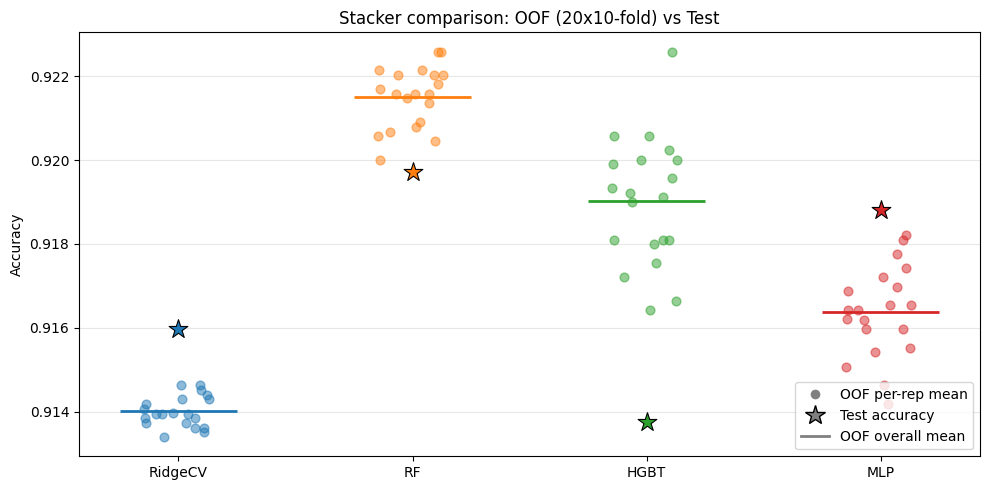

In [11]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import RidgeClassifierCV
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Build probability matrix from level-0 neki predictions
df = pl.DataFrame(m.neki).filter(pl.col("level") == 0)
prob_matrix = df.pivot(on="class", index=["index", "model"], values="probability", aggregate_function='mean')
class_cols = [c for c in prob_matrix.columns if c not in ("index", "model")]
wide = prob_matrix.pivot(on="model", index="index", values=class_cols)
wide = wide.sort("index")
X_stack = wide.drop("index").to_numpy()

le = LabelEncoder()
y_enc = le.fit_transform(y_train)

stackers = {
    "RidgeCV": RidgeClassifierCV(alphas=np.logspace(-3, 3, 20)),
    "RF": RandomForestClassifier(n_estimators=200, n_jobs=-1),
    "HGBT": HistGradientBoostingClassifier(max_iter=200),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=500),
}

N_REPEATS = 20
rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=N_REPEATS, random_state=42)
results = {name: [] for name in stackers}

for fold_i, (tr_idx, val_idx) in enumerate(rskf.split(X_stack, y_enc)):
    rep = fold_i // 10
    for name, clf in stackers.items():
        clf_copy = clf.__class__(**clf.get_params())
        clf_copy.fit(X_stack[tr_idx], y_enc[tr_idx])
        acc = accuracy_score(y_enc[val_idx], clf_copy.predict(X_stack[val_idx]))
        results[name].append({"rep": rep, "fold": fold_i % 10, "acc": acc})

# Build test probability matrix
test_preds = m.predict_proba_per_model(X_test)
train_cols = wide.drop("index").columns

test_records = []
for model_name, proba_arr in test_preds.items():
    if model_name in m.stacking_models:
        continue
    classes_ = list(m.classes_)
    for i in range(proba_arr.shape[0]):
        for j, cls in enumerate(classes_):
            test_records.append({"index": i, "model": model_name, "level": 0, "class": str(cls), "probability": proba_arr[i, j]})

df_test = pl.DataFrame(test_records)
prob_matrix_test = df_test.pivot(on="class", index=["index", "model"], values="probability")
class_cols_test = [c for c in prob_matrix_test.columns if c not in ("index", "model")]
wide_test = prob_matrix_test.pivot(on="model", index="index", values=class_cols_test)
wide_test = wide_test.sort("index")
X_stack_test = wide_test.select(train_cols).to_numpy()
y_test_enc = le.transform(y_test)

# Test set accuracy
test_accs = {}
for name, clf in stackers.items():
    clf_final = clf.__class__(**clf.get_params())
    clf_final.fit(X_stack, y_enc)
    test_accs[name] = accuracy_score(y_test_enc, clf_final.predict(X_stack_test))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
names = list(stackers.keys())
x_positions = np.arange(len(names))

for i, name in enumerate(names):
    rdf = pl.DataFrame(results[name])
    per_rep = rdf.group_by("rep").agg(pl.col("acc").mean()).sort("rep")["acc"].to_numpy()
    # scatter all per-rep OOF accuracies
    jitter = np.random.default_rng(0).uniform(-0.15, 0.15, size=len(per_rep))
    ax.scatter(np.full_like(per_rep, i) + jitter, per_rep, alpha=0.5, s=40, zorder=3, label=f"{name} OOF reps" if i == 0 else None, color=f"C{i}")
    # mean OOF line
    ax.hlines(per_rep.mean(), i - 0.25, i + 0.25, colors=f"C{i}", linewidths=2, zorder=4)
    # test accuracy marker
    ax.scatter(i, test_accs[name], marker="*", s=200, color=f"C{i}", edgecolors="black", linewidths=0.8, zorder=5)
    print(f"{name:8s}  OOF mean={per_rep.mean():.4f} std={per_rep.std():.4f}  test={test_accs[name]:.4f}")

ax.set_xticks(x_positions)
ax.set_xticklabels(names)
ax.set_ylabel("Accuracy")
ax.set_title(f"Stacker comparison: OOF ({N_REPEATS}x10-fold) vs Test")
# custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markersize=8, label="OOF per-rep mean"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="gray", markeredgecolor="black", markersize=15, label="Test accuracy"),
    Line2D([0], [0], color="gray", linewidth=2, label="OOF overall mean"),
]
ax.legend(handles=legend_elements, loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
